### **1. Linear Regression**

#### 1.1 Linear Model

* Given an $n$-dimensional input: $\mathbf{x} = [x_1, x_2, \dots, x_n]^T$
* A linear model has an $n$-dimensional weight vector and a scalar bias:
    $$\mathbf{w} = [w_1, w_2, \dots, w_n]^T, \quad b$$
* The output is a weighted sum of the inputs:
    $$y = w_1x_1 + w_2x_2 + \dots + w_nx_n + b$$

    Vectorized version: $y = \langle\mathbf{w}, \mathbf{x}\rangle + b$

#### 1.2 Case Example: House Price 
##### Measuring Prediction Quality

* Compare the true value with the predicted value, for example, actual house sale prices versus estimated prices.
* Assume $y$ is the true value and $\hat{y}$ is the estimated value, we can compare them using:
    $$\ell(y, \hat{y}) = \frac{1}{2}(y - \hat{y})^2$$

This is called the **squared loss**.

#### 1.3 Training Data

* Collect data points to determine parameter values (weights and bias), such as houses sold over the past 6 months.
* This is called **training data**.
* Generally, the more data, the better.
* Assume we have $n$ examples, denoted as:
    $$\mathbf{X} = [\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_n]^T, \quad \mathbf{y} = [y_1, y_2, \dots, y_n]^T$$

#### 1.4 Parameter Learning

* **Training Loss:**
    $$\ell(\mathbf{X}, \mathbf{y}, \mathbf{w}, b) = \frac{1}{2n} \sum_{i=1}^{n} \left(y_i - \langle\mathbf{x}_i, \mathbf{w}\rangle - b\right)^2 = \frac{1}{2n} \|\mathbf{y} - \mathbf{X}\mathbf{w} - b\|^2$$

* **Learn parameters by minimizing the loss:**
    $$\mathbf{w}^*, b^* = \arg\min_{\mathbf{w}, b} \ell(\mathbf{X}, \mathbf{y}, \mathbf{w}, b)$$

#### 1.5 Linear Regression: Analytical Solution (Normal Equation)

##### 1.5.1 The Trick: Absorbing the Bias
To simplify the notation, we absorb the bias $b$ into the weight vector $\mathbf{w}$ and add a column of ones to the feature matrix $\mathbf{X}$:
$$\mathbf{X} \leftarrow [\mathbf{X}, \mathbf{1}], \quad \mathbf{w} \leftarrow \begin{bmatrix} \mathbf{w} \\ b \end{bmatrix}$$
This allows us to write the prediction simply as $\hat{\mathbf{y}} = \mathbf{X}\mathbf{w}$.

##### 1.5.2 Loss Function (Mean Squared Error)
The loss function measures the average squared difference between the true labels $\mathbf{y}$ and predictions $\mathbf{X}\mathbf{w}$:
$$\ell(\mathbf{X}, \mathbf{y}, \mathbf{w}) = \frac{1}{2n} \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2 = \frac{1}{2n} (\mathbf{y} - \mathbf{X}\mathbf{w})^T(\mathbf{y} - \mathbf{X}\mathbf{w})$$

##### 1.5.3 Optimization via Convexity
Since the MSE loss is a **convex function**, its global minimum occurs where the gradient (partial derivative) with respect to $\mathbf{w}$ is zero:
$$\frac{\partial}{\partial \mathbf{w}}\ell(\mathbf{X}, \mathbf{y}, \mathbf{w}) = \frac{1}{n}(\mathbf{y} - \mathbf{X}\mathbf{w})^T\mathbf{X} = \mathbf{0}$$

**Recap:** $$\frac{\partial}{\partial \mathbf{w}}(\mathbf{w}^T\mathbf{A}\mathbf{w}) = 2\mathbf{w}^T\mathbf{A}$$

##### 1.5.4 Solving for $\mathbf{w}^*$
Setting the gradient to zero and solving for $\mathbf{w}$:
$$\mathbf{X}^T(\mathbf{y} - \mathbf{X}\mathbf{w}) = \mathbf{0}$$
$$\mathbf{X}^T\mathbf{y} - \mathbf{X}^T\mathbf{X}\mathbf{w} = \mathbf{0}$$
$$\mathbf{X}^T\mathbf{X}\mathbf{w} = \mathbf{X}^T\mathbf{y}$$

Multiplying both sides by the inverse $(\mathbf{X}^T\mathbf{X})^{-1}$ yields the **Normal Equation**:
$$\mathbf{w}^* = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

#### **Summary: Linear Regression**

* Linear regression applies weights to $n$-dimensional inputs and adds a bias.
* It uses squared loss to measure the difference between predicted and true values.
* Linear regression has an analytical solution (closed-form solution).
* Linear regression can be viewed as a single-layer neural network.

### **2 Basic Optimization Algorithms**

#### 2.1 Gradient Descent
- **Initialization:** Pick an initial parameter value $\mathbf{w}_0$.
- **Iteration:** Repeat updating the parameters for $t = 1, 2, 3, \dots$
  $$\mathbf{w}_t = \mathbf{w}_{t-1} - \eta \frac{\partial \ell}{\partial \mathbf{w}_{t-1}}$$
- **Concept:** Moving along the gradient direction increases the value of the loss function, so we subtract the gradient to minimize the loss.
- **Learning Rate ($\eta$):** A hyperparameter that determines the step size of each update.

#### 2.2 Minibatch Stochastic Gradient Descent (SGD)
- **Motivation:** Computing the gradient over the entire training set is computationally too expensive. For a deep neural network model, a single update could take minutes to hours.
- **Approximation:** We can randomly sample $b$ examples $i_1, i_2, \dots, i_b$ to approximate the overall loss:
  $$\frac{1}{b} \sum_{i \in I_b} \ell(\mathbf{x}_i, y_i, \mathbf{w})$$
- **Batch Size ($b$):** Another critical hyperparameter representing the number of samples in each batch.

#### 2.3 Choosing Batch Size
- **Cannot be too small:** If the computational load per iteration is too small, it is not suitable for maximizing the utilization of computational resources through parallel processing.
- **Cannot be too large:** Significantly increases memory consumption. It may also lead to wasted computation (for example, if all samples happen to be identical or highly similar, redundant calculations don't provide extra gradient information).

#### 2.4 Summary
- **Optimization Strategy:** Gradient descent solves for parameters by continuously updating them along the negative gradient direction.
- **Default Algorithm:** Minibatch Stochastic Gradient Descent is the default solving algorithm used in deep learning.
- **Key Hyperparameters:** The two most important hyperparameters are the **Batch Size** and the **Learning Rate**.

### **3 Linear Regression (Start From Scratch)**

In [2]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

#### Example:
Generate a synthetic dataset based on a linear model with noise. 
We use the linear model parameters $$\mathbf{w} = [2, -3.4]^\top$$ $$b = 4.2$$ and a noise term $\epsilon$ to generate the dataset and its labels:

$$\mathbf{y} = \mathbf{X}\mathbf{w} + b + \epsilon$$

#### 3.1 Creating a Synthetic Dataset

This function creates fake training data so that we already know the correct answer.
That makes it easier to check whether our training code can learn the right parameters.

Important ideas in this cell:

* `w` is the true weight vector. In this example it has 2 values, so every input example has 2 features.
* `b` is the true bias, a single scalar added to every prediction.
* `num_examples` is the number of rows we want to generate.
* `torch.normal(0, 1, (num_examples, len(w)))` creates a feature matrix `x` with shape `(num_examples, number_of_features)`.
* `torch.matmul(x, w)` computes the linear part of the model for every row in `x`.
* The small random noise term makes the data more realistic. Real data usually does not lie perfectly on one exact line or plane.
* `y.reshape((-1, 1))` turns the labels into a column vector with shape `(num_examples, 1)`, which matches the shape expected later by the loss function.

So after this cell, `features` is the input data and `labels` is the target value we want the model to predict.


In [3]:
def synthetic_data(w,b,num_examples):
    """Generate y=wx+b+ε"""
    x=torch.normal(0,1,(num_examples,len(w)))
    y=torch.matmul(x,w)+b
    y+=torch.normal(0,0.01,y.shape)
    return x,y.reshape((-1,1))

true_w=torch.tensor([2,-3.4])
true_b=4.2
features,labels=synthetic_data(true_w,true_b,1000)

In [4]:
# Each row in features contains a two-dimensional data sample, 
# and each row in labels contains a one-dimensional label value (a scalar)
print('features:',features[0],'\nlabel:',labels[0])

features: tensor([-1.1341, -1.1995]) 
label: tensor([6.0199])


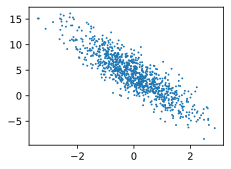

In [5]:
d2l.set_figsize()
d2l.plt.scatter(features[:,1].detach().numpy(),\
                labels.detach().numpy(),1);

#### 3.2 Mini-Batch Data Iterator: `data_iter`

Training usually does not use the whole dataset for every single parameter update.
Instead, we split the dataset into small groups called **mini-batches**.
`data_iter` is a small generator function that returns one mini-batch at a time.

What the function receives:

* `batch_size`: how many examples we want in one mini-batch.
* `features`: the full input matrix. Each row is one training example.
* `labels`: the full label matrix/vector. Each row is the answer for the matching row in `features`.

Step by step:

1. `num_examples = len(features)` gets the number of training examples.
2. `indices = list(range(num_examples))` creates a list like `[0, 1, 2, ..., 999]`.
3. `random.shuffle(indices)` randomly changes the order of those row numbers.
   This is important because SGD works better when batches are not always seen in the same fixed order.
4. `for i in range(0, num_examples, batch_size)` moves through the shuffled index list in jumps of `batch_size`.
   If `batch_size = 10`, then `i` becomes `0, 10, 20, ...`.
5. `indices[i:min(i + batch_size, num_examples)]` selects the row numbers for the current mini-batch.
   The `min(...)` protects the last batch in case the dataset size is not exactly divisible by `batch_size`.
6. `torch.tensor(...)` converts those Python row numbers into a tensor, so PyTorch can use them for indexing.
7. `features[batch_indices]` and `labels[batch_indices]` select the matching rows from the full dataset.
8. `yield` returns the current mini-batch, but keeps the function paused so it can continue later with the next mini-batch.

The key difference between `yield` and `return`:

* `return` would give back one result and then stop the function completely.
* `yield` gives back one result at a time, which is why we can write `for x, y in data_iter(...)`.

In the small test below, we print only the first mini-batch and then use `break` to stop early.


In [6]:
# Define a data_iter function that takes the batch size, feature matrix, 
# and label vector as inputs, and generates mini-batches of size batch_size
def data_iter(batch_size,features,labels):
    num_examples=len(features)
    indices=list(range(num_examples))
    # These examples are read randomly with no particular order
    random.shuffle(indices)
    for i in range(0,num_examples,batch_size):
        batch_indices=torch.tensor(indices[i:min(i+batch_size,num_examples)])
        yield features[batch_indices],labels[batch_indices]

batch_size=10

for x,y in data_iter(batch_size,features,labels):
    print(x,'\n',y)
    break

tensor([[-1.5214, -1.0603],
        [ 1.7939,  0.1548],
        [ 0.1195, -0.2613],
        [ 0.7486,  0.9506],
        [-0.9049, -0.0390],
        [ 0.3139,  0.2302],
        [-1.5762, -1.5214],
        [-0.1971, -1.5007],
        [-1.9711, -1.1555],
        [ 0.4229, -0.3982]]) 
 tensor([[4.7854],
        [7.2447],
        [5.3248],
        [2.4659],
        [2.5286],
        [4.0434],
        [6.2299],
        [8.8824],
        [4.1905],
        [6.4041]])


#### 3.2.1 Model Parameters, Model, Loss, and Optimizer

The next four code blocks define the core pieces needed before training linear regression from scratch.

* **Model parameters**: `w` stores the two feature weights and is initialized from a normal distribution with small random values. `b` stores the bias term and starts at zero. Both tensors use `requires_grad=True` so PyTorch can track operations on them and compute gradients during backpropagation.
* **Model function**: `linreg(x, w, b)` implements the linear regression formula `Xw + b`. `torch.matmul(x, w)` computes the weighted sum for every example in the mini-batch, and adding `b` shifts every prediction by the same bias term.
* **Loss function**: `squared_loss(y_hat, y)` measures prediction error with squared loss. `y.reshape(y_hat.shape)` makes the label tensor match the prediction tensor shape, and dividing by `2` simplifies the gradient of the squared term.
* **Optimization algorithm**: `sgd(params, lr, batch_size)` manually applies mini-batch stochastic gradient descent. Each parameter is moved in the opposite direction of its gradient, scaled by the learning rate and averaged over the batch size. `param.grad.zero_()` clears old gradients so the next mini-batch starts fresh.


In [7]:
# Initialize model parameters
w=torch.normal(0,0.01,size=(2,1),requires_grad=True)
b=torch.zeros(1,requires_grad=True)

In [9]:
# Define the model
def linreg(x,w,b):
    """Linear Regression Model"""
    return torch.matmul(x,w)+b

In [10]:
# Define the loss function
def squared_loss(y_hat,y):
    """Squared loss for linear regression."""
    return (y_hat-y.reshape(y_hat.shape))**2/2

In [13]:
# Define the optimization algorithm
def sgd(params,lr,batch_size):
    """Mini-batch stochastic gradient descent."""
    with torch.no_grad():
        for param in params:
            param-=lr*param.grad/batch_size
            param.grad.zero_()

#### 3.3 Training Loop: Understanding `for epoch`

An **epoch** means one complete pass through the training dataset.
If `num_epochs = 3`, the model will look at the full dataset 3 times.

Before the loop:

* `lr = 0.03` is the learning rate. It controls how large each parameter update is.
* `num_epochs = 3` means we repeat training for 3 full passes over the data.
* `net = linreg` means the model function is linear regression.
* `loss = squared_loss` means the loss function measures prediction error using squared loss.

This training loop has two levels:

1. Outer loop: `for epoch in range(num_epochs)`
   * Controls how many full passes we make over the dataset.
   * With `num_epochs = 3`, `epoch` takes values `0`, `1`, and `2`.
   * We print `epoch + 1` because humans usually count epochs starting from 1.

2. Inner loop: `for x, y in data_iter(batch_size, features, labels)`
   * Gets one mini-batch at a time.
   * `x` contains a small group of input examples.
   * `y` contains the matching true labels.
   * The model updates its parameters once per mini-batch.

Inside one mini-batch update:

* `net(x, w, b)` computes the predictions for the current mini-batch.
* `loss(net(x, w, b), y)` compares predictions with true labels.
* `l.sum().backward()` asks PyTorch autograd to compute gradients for `w` and `b`.
  We use `.sum()` because `l` contains one loss value per example, but `.backward()` needs a scalar value.
* `sgd([w, b], lr, batch_size)` updates `w` and `b` using the gradients.

After each epoch:

* `with torch.no_grad()` tells PyTorch that we are only checking the loss, not training.
  This saves memory and avoids building an unnecessary computation graph.
* `train_l = loss(net(features, w, b), labels)` computes the loss over the whole dataset.
* The `print(...)` line shows whether the training loss is going down after each epoch.

Expected result: because the data was generated from `true_w = [2, -3.4]` and `true_b = 4.2`, the learned `w` and `b` should become close to those values after training.


In [14]:
# Training process
lr=0.03
num_epochs=3
net=linreg
loss=squared_loss

for epoch in range(num_epochs):
    for x, y in data_iter(batch_size,features,labels):
        l = loss(net(x, w, b), y)  # Mini-batch loss for x and y
        # Because l has shape (batch_size, 1) instead of being a scalar,
        # all elements in l are summed together to compute the gradients with respect to [w, b]
        l.sum().backward()
        sgd([w, b], lr, batch_size)  # Update parameters using their gradients
    with torch.no_grad():
        train_l=loss(net(features,w,b),labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.032729
epoch 2, loss 0.000128
epoch 3, loss 0.000051


### **4 Simplified Linear Regression**

#### 4.1 Framework Implementation Notes

This section reimplements linear regression using PyTorch utilities instead of manually writing every component. The overall workflow is the same as the from-scratch version: create data, build a model, define a loss function, choose an optimizer, and train for several epochs.

**Data preparation**

* `synthetic_data(true_w, true_b, 1000)` creates the same synthetic regression dataset used earlier. The inputs have two features, and the labels are generated from the true linear rule plus random noise.
* `data.TensorDataset(*data_arrays)` wraps the feature tensor and label tensor into one dataset object. Each item returned by this dataset is a matching `(feature, label)` pair.
* `data.DataLoader(dataset, batch_size, shuffle=is_train)` creates a mini-batch iterator. When `shuffle=True`, PyTorch randomly shuffles examples before forming batches, which is useful during training.
* `next(iter(data_iter))` takes one mini-batch from the iterator so we can inspect the data shape and contents.

**Model definition and initialization**

* `nn.Linear(2, 1)` creates a linear layer with two input features and one output value. Internally, it stores a weight matrix and a bias term.
* `nn.Sequential(...)` puts layers into an ordered container. Here there is only one layer, so `net(x)` simply applies that linear layer to `x`.
* `net[0]` accesses the first layer inside the sequential model. This is why `net` must refer to the `nn.Sequential` model before using `net[0]`. If `net` still refers to the earlier `linreg` function, Python raises `TypeError: 'function' object is not subscriptable`.
* `net[0].weight.data.normal_(0, 0.01)` initializes the layer weights with small random values from a normal distribution.
* `net[0].bias.data.fill_(0)` initializes the bias term to zero.

**Loss function and optimizer**

* `nn.MSELoss()` creates the mean squared error loss function. It compares predictions and labels, squares the differences, and averages them into one scalar loss value.
* `torch.optim.SGD(net.parameters(), lr=0.03)` creates a stochastic gradient descent optimizer. `net.parameters()` gives the optimizer the model parameters it should update, and `lr=0.03` sets the learning rate.
* `trainer.zero_grad()` clears old gradients before computing new ones. PyTorch accumulates gradients by default, so this step is required in each mini-batch update.
* `l.backward()` computes gradients of the loss with respect to the model parameters.
* `trainer.step()` updates the model parameters using the gradients and the SGD rule.

**Training loop**

* The outer loop `for epoch in range(num_epochs)` controls how many full passes the model makes over the dataset.
* The inner loop `for x, y in data_iter` reads one mini-batch at a time.
* `l = loss(net(x), y)` runs the model on the current mini-batch and computes the prediction error.
* After all mini-batches in one epoch are processed, `loss(net(features), labels)` evaluates the loss on the full dataset and prints the training progress.


In [19]:
# Use the deep learning framework
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

true_w=torch.tensor([2,-3.4])
true_b=4.2
features,labels=synthetic_data(true_w,true_b,1000)

In [20]:
# Use the framework API to read data
def load_array(data_arrays,batch_size,is_train=True):
    """Construct a PyTorch data iterator."""
    dataset=data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset,batch_size,shuffle=is_train)

batch_size=10
data_iter=load_array((features,labels),batch_size)

next(iter(data_iter))

[tensor([[ 0.6407, -0.2114],
         [-0.8736,  0.8851],
         [ 1.3827,  2.2188],
         [ 0.2931,  0.0937],
         [-0.6816,  0.3369],
         [-1.0093,  1.7952],
         [ 0.6445,  1.8201],
         [-1.2979, -0.5900],
         [-0.7224,  0.9666],
         [ 2.1872,  0.5633]]),
 tensor([[ 6.1869],
         [-0.5462],
         [-0.5700],
         [ 4.4775],
         [ 1.6854],
         [-3.9228],
         [-0.7088],
         [ 3.6145],
         [-0.5258],
         [ 6.6412]])]

In [21]:
# Use framework-defined layers
from torch import nn

net=nn.Sequential(nn.Linear(2,1))

In [22]:
# Initialize model parameters
net[0].weight.data.normal_(0,0.01)
net[0].bias.data.fill_(0)

tensor([0.])

In [23]:
# Use MSELoss to compute mean squared error, also known as the squared L2 norm
loss=nn.MSELoss()

In [24]:
# Create an SGD optimizer instance
trainer=torch.optim.SGD(net.parameters(),lr=0.03)

In [27]:
# The training loop is similar to the from-scratch implementation
num_epochs=3
for epoch in range(num_epochs):
    for x,y in data_iter:
        l=loss(net(x),y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l=loss(net(features),labels)
    print(f'epoch {epoch+1},loss {l:f}')

epoch 1,loss 0.000093
epoch 2,loss 0.000094
epoch 3,loss 0.000094
